In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Telco_Customer_Churn_Dataset  (3) (1).csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
# # df.head()

# # df.shape

# df.info()

# # df.describe()

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

# Data Cleaning

Data cleaning is an essential step in the data science workflow. It involves identifying and correcting issues in the dataset to improve its quality and reliability.

In this section, we will:

- Identify incorrect data types.
- Check for invalid or blank values.
- Convert columns to their appropriate data types.
- Prepare the dataset for Exploratory Data Analysis (EDA) and Machine Learning.

## Checking the `TotalCharges` Column

The `TotalCharges` column should contain numerical values representing the total amount charged to a customer.

However, during dataset inspection, we found that its data type is `object` instead of a numeric type. This may indicate the presence of blank spaces or other non-numeric values.

We will inspect this column before converting it to a numeric data type.

In [10]:
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [11]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

## Converting `TotalCharges` to Numeric

The `TotalCharges` column contains 11 blank string values (`" "`), which prevent it from being recognized as a numeric column.

To resolve this issue, we convert the column to a numeric data type using `pd.to_numeric()`. Any invalid values (such as blank strings) are automatically converted to `NaN` using the `errors='coerce'` parameter.

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [13]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of analyzing and visualizing data to understand its structure, identify patterns, detect anomalies, and extract meaningful insights.

The objective of EDA in this project is to:

- Understand customer churn behavior.
- Identify factors influencing churn.
- Discover relationships between different variables.
- Support feature selection for machine learning.

## Churn Distribution

The first step in EDA is to examine the distribution of the target variable (`Churn`).

This visualization helps us understand the proportion of customers who have stayed versus those who have left the company.

Knowing the class distribution is important because an imbalanced dataset may influence machine learning model performance.

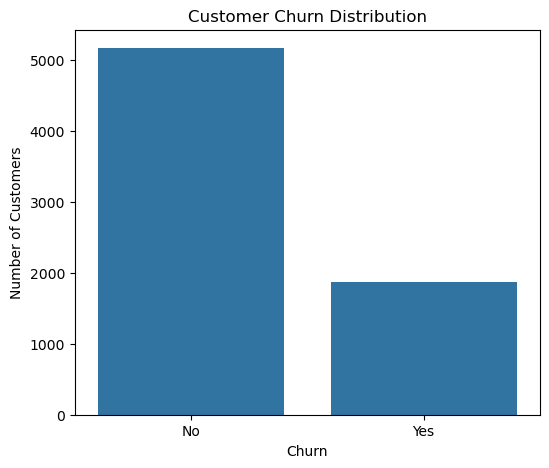

In [17]:
plt.figure(figsize=(6,5))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- The majority of customers have **not churned**.
- Approximately **73%** of customers stayed with the company.
- Around **27%** of customers left the company.
- The dataset is moderately imbalanced, which should be considered during model evaluation.

## Gender vs Customer Churn

This analysis compares customer churn across different genders.

The objective is to determine whether male or female customers are more likely to leave the company's services.

Understanding this relationship helps identify whether gender has any significant influence on customer retention.

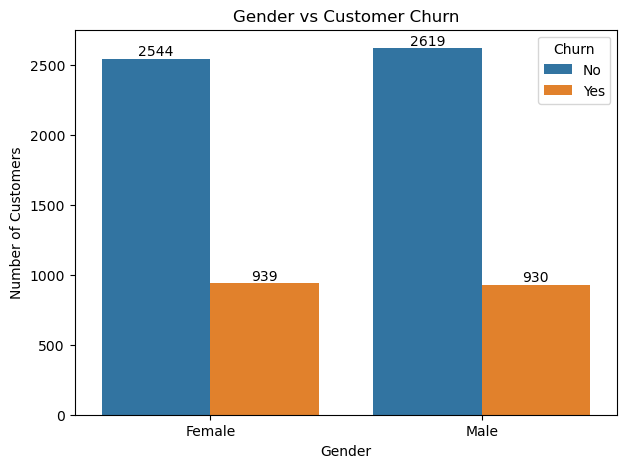

In [18]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x='gender', hue='Churn', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

### Observation

- The number of male and female customers is nearly equal.
- Both genders exhibit a similar number of churned customers.
- There is no significant difference in churn behavior between male and female customers.
- This indicates that gender does not appear to have a strong influence on customer churn.

### Business Insight

Since churn is nearly identical for both male and female customers, the company should not design gender-specific retention strategies.

Instead, efforts should focus on factors such as contract type, tenure, internet service, and monthly charges, which are more likely to influence customer churn.

## Senior Citizen vs Customer Churn

This analysis examines whether senior citizens are more likely to churn compared to non-senior customers.

Understanding this relationship helps the company identify whether age-related factors influence customer retention and whether specialized retention strategies are required for senior customers.

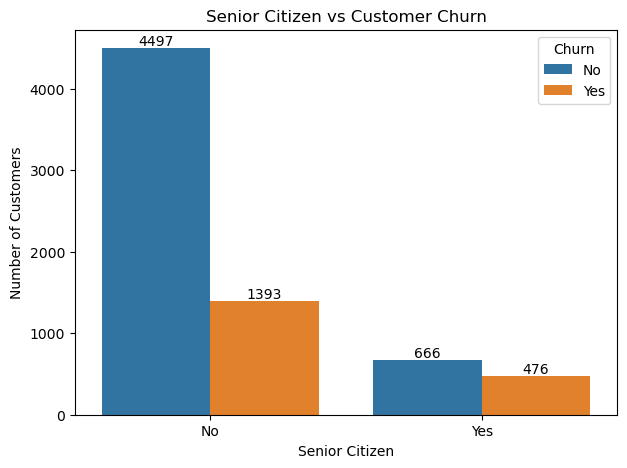

In [19]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.xticks([0,1], ["No", "Yes"])

plt.legend(title="Churn")

plt.show()

### Observation

- Senior citizens have a significantly higher churn rate than non-senior customers.
- Approximately **41.68%** of senior citizens have churned, compared to only **23.65%** of non-senior customers.
- This indicates that senior citizen status has a noticeable influence on customer churn.
- Therefore, the `SeniorCitizen` feature is likely to be an important predictor in the machine learning model.

In [20]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


### Business Insight

Senior citizens are more likely to discontinue the company's services compared to younger customers.

The company should design customer retention programs specifically for senior citizens, such as dedicated customer support, simplified service plans, personalized assistance, or loyalty benefits to improve customer satisfaction and reduce churn.

## Partner vs Customer Churn

This analysis examines whether having a partner influences customer churn.

Understanding this relationship helps determine whether customers with family commitments are more likely to remain loyal to the company's services.

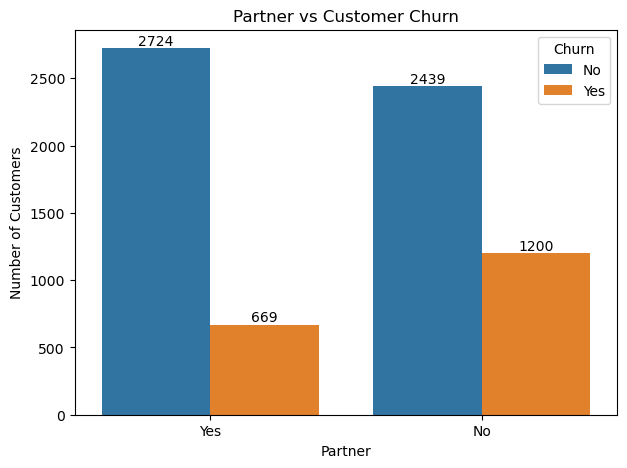

In [21]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x='Partner', hue='Churn', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Partner vs Customer Churn")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

### Observation

- Customers without a partner have a noticeably higher churn rate than customers with a partner.
- Approximately **32.98%** of customers without a partner have churned.
- In comparison, only **19.72%** of customers with a partner have churned.
- This suggests that customers with a partner are more likely to remain loyal to the company's services.

In [22]:
pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


### Business Insight

Customers without a partner are at a higher risk of churning.

The company can target these customers with personalized offers, loyalty programs, or flexible subscription plans to improve customer retention.

## Dependents vs Customer Churn

This analysis explores whether having dependents influences customer churn.

Customers with dependents may have different service usage patterns and loyalty levels compared to those without dependents. Understanding this relationship can help the company identify customer groups that require targeted retention strategies.

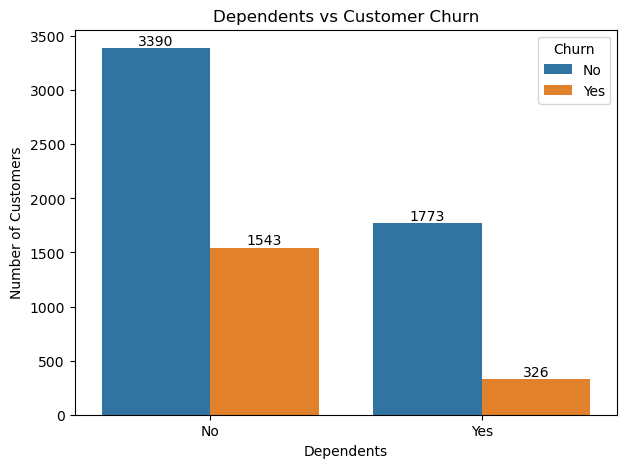

In [23]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x='Dependents', hue='Churn', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Dependents vs Customer Churn")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

### Observation

- Customers without dependents have a significantly higher churn rate than customers with dependents.
- Approximately **31.28%** of customers without dependents have churned.
- In contrast, only **15.53%** of customers with dependents have churned.
- This suggests that customers with dependents are more likely to remain loyal to the company's services.
- Therefore, the `Dependents` feature is likely to have a meaningful impact on customer churn prediction.

In [24]:
pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


### Business Insight

Customers without dependents are more likely to discontinue the company's services.

The company can improve retention by offering personalized plans, discounts, or loyalty programs specifically targeted at customers without dependents.

# Business Recommendations from Categorical Analysis

Based on the exploratory data analysis, the following recommendations can help reduce customer churn:

- Encourage customers to switch from month-to-month contracts to yearly contracts by offering discounts or loyalty benefits.
- Promote Online Security and Tech Support services, as customers using these services are less likely to churn.
- Investigate the reasons behind the high churn rate among Fiber Optic customers and improve service quality if necessary.
- Develop special retention strategies for senior citizens, who exhibit a relatively higher churn rate.
- Offer personalized plans and retention campaigns for customers without partners or dependents, as they are more likely to discontinue the service.
- Monitor customers using electronic check payments and provide incentives for alternative payment methods if appropriate.

## Distribution of Customer Tenure

The `tenure` column represents the number of months a customer has stayed with the company.

Analyzing its distribution helps us understand customer retention patterns and identify whether most customers are new or long-term subscribers.

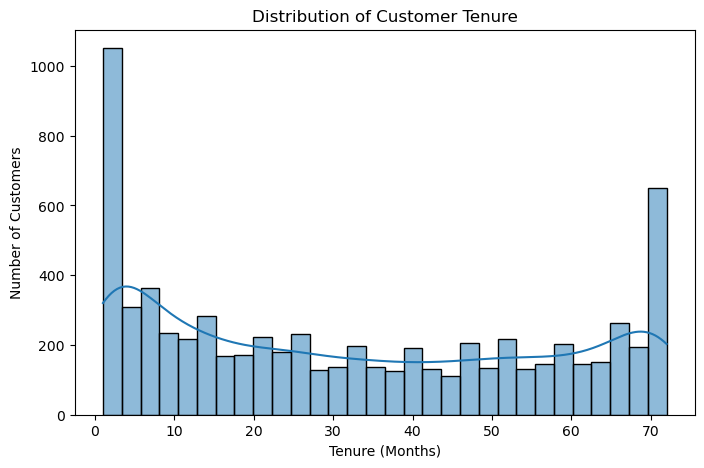

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

## Distribution of Monthly Charges

This visualization shows how monthly charges are distributed among customers.

It helps identify common billing ranges and detect any unusual patterns in customer payments.

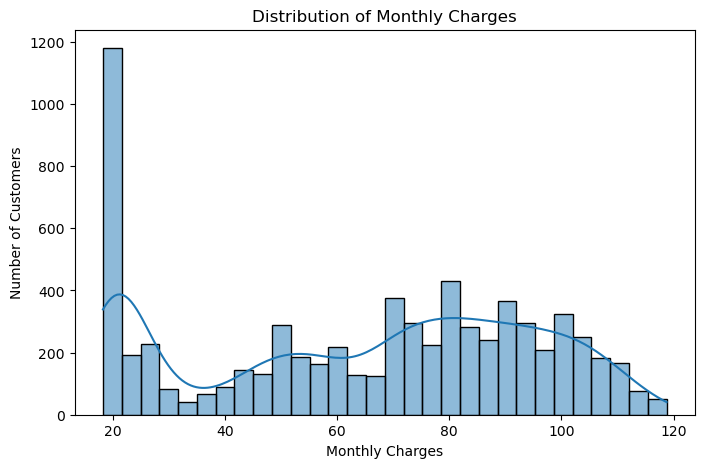

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

## Distribution of Total Charges

The `TotalCharges` column represents the cumulative amount paid by each customer.

This distribution provides insight into customers' overall spending and highlights any skewness or outliers in the data.

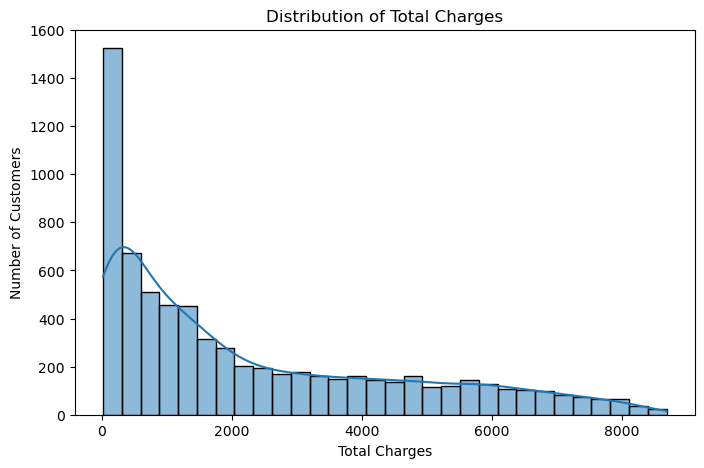

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["TotalCharges"], bins=30, kde=True)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

## Customer Tenure vs Churn

This visualization compares customer tenure between churned and retained customers.

It helps determine whether customers with shorter or longer service durations are more likely to discontinue the service.

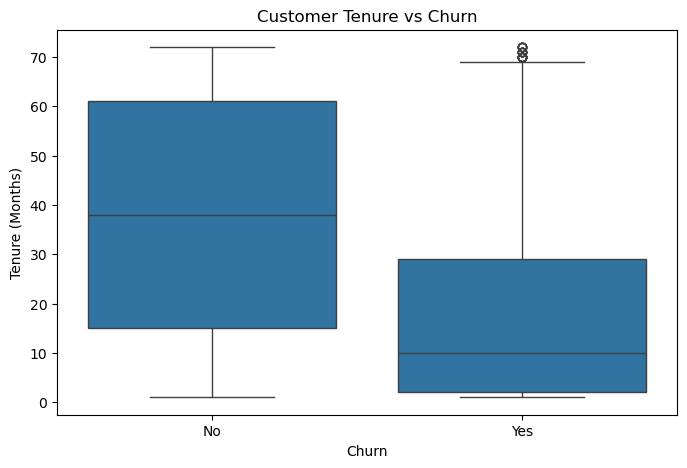

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

## Monthly Charges vs Churn

This analysis compares monthly charges between customers who churned and those who remained with the company.

It helps identify whether higher monthly charges contribute to customer churn.

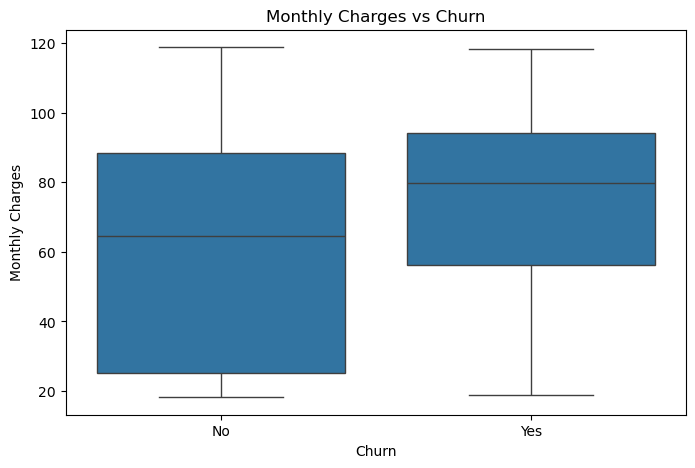

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

## Total Charges vs Churn

This visualization compares the total amount paid by customers based on their churn status.

It helps determine whether long-term spending influences customer retention.

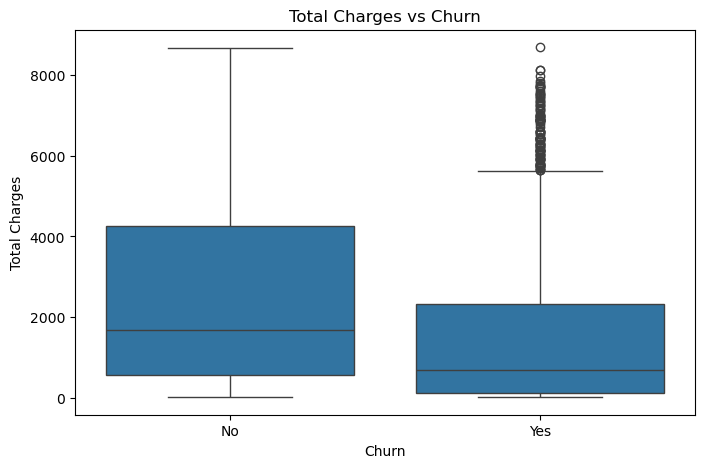

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="TotalCharges", data=df)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

## Correlation Heatmap

The correlation heatmap illustrates the relationships between numerical variables in the dataset.

Correlation values range from **-1** to **1**, where:

- **1** indicates a perfect positive correlation.
- **-1** indicates a perfect negative correlation.
- **0** indicates no linear relationship.

This visualization helps identify strongly related numerical features.

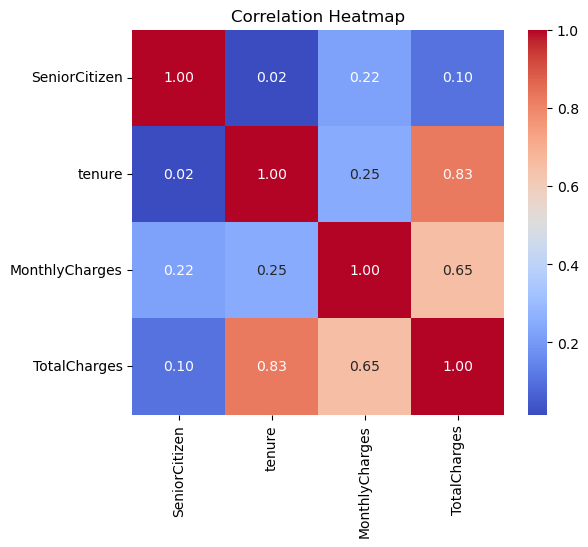

In [31]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Overall Findings from Exploratory Data Analysis

The exploratory data analysis revealed several important factors influencing customer churn.

### Major Findings

- Customers with month-to-month contracts are more likely to churn.
- Senior citizens exhibit a higher churn rate than non-senior customers.
- Customers without partners or dependents are more likely to leave.
- Fiber optic internet users show a higher churn rate than other internet service users.
- Customers without Online Security and Tech Support services churn significantly more.
- Higher monthly charges are associated with increased churn.
- Customers with shorter tenure are much more likely to churn.
- Longer customer tenure contributes to higher total revenue, making customer retention essential for business growth.

These insights will guide feature selection and help build an effective machine learning model for churn prediction.

# Feature Engineering

Feature engineering is the process of preparing data for machine learning by selecting relevant features, converting categorical variables into numerical values, and transforming the dataset into a suitable format for model training.

The objective of this phase is to improve model performance and ensure compatibility with machine learning algorithms.

## Removing Unnecessary Columns

The `customerID` column is a unique identifier assigned to each customer.

Since it does not contain any meaningful information related to customer churn, it is removed from the dataset before model training.

In [32]:
df.drop("customerID", axis=1, inplace=True)

In [33]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Encoding the Target Variable

The target variable (`Churn`) contains categorical values (`Yes` and `No`).

Machine learning algorithms require numerical values, so the target variable is encoded as follows:

- No → 0
- Yes → 1

In [34]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [35]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [36]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

## Encoding Categorical Features

Most machine learning algorithms require numerical input.

Therefore, categorical variables are transformed into numerical representations using **One-Hot Encoding**, which creates separate binary columns for each category without introducing any artificial ordering.

In [37]:
df = pd.get_dummies(df, drop_first=True)

In [38]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [40]:
df.shape

(7032, 31)

In [41]:
df = df.astype(int)

In [42]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


## Splitting Features and Target Variable

The dataset is divided into:

- **Features (X):** All independent variables used for prediction.
- **Target Variable (y):** The `Churn` column, which represents whether a customer has churned or not.

Separating the features and target variable is an essential step before training machine learning models.

In [43]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [44]:
print(X.shape)

print(y.shape)

(7032, 30)
(7032,)


## Splitting the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets.

- **Training Set (80%)** is used to train the machine learning model.
- **Testing Set (20%)** is used to evaluate the model on unseen data.

Using separate training and testing datasets helps measure how well the model generalizes to new customers.

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


# Machine Learning Model

## Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

In this project, it predicts whether a customer is likely to churn (`1`) or not (`0`) based on customer-related features.

It serves as a baseline model for evaluating and comparing the performance of other classification algorithms.

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Model Training

The Logistic Regression model is trained using the training dataset.

The model learns patterns from historical customer data and attempts to predict customer churn for unseen customers.

In [49]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Prediction

After training, the model is used to predict customer churn on the testing dataset.

In [50]:
y_pred = lr.predict(X_test)

## Model Accuracy

Accuracy measures the proportion of correctly classified instances out of the total number of predictions.

In [51]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7867803837953091


## Confusion Matrix

A confusion matrix summarizes the model's prediction results by comparing actual values with predicted values.

It provides detailed insight into:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

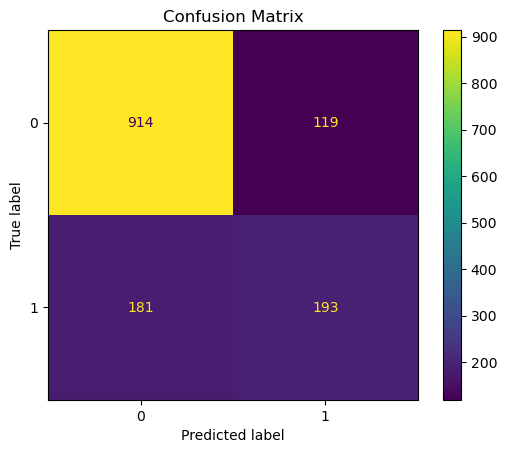

In [52]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

## Classification Report

The classification report provides detailed evaluation metrics including:

- Precision
- Recall
- F1-Score
- Support

These metrics provide a more comprehensive evaluation than accuracy alone.

In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Logistic Regression Results

### Observation

- The Logistic Regression model achieved an accuracy of **78.68%**.
- The model correctly classified **914** non-churn customers and **193** churn customers.
- The recall for churn prediction is **52%**, indicating that the model successfully identifies just over half of the customers who are likely to churn.
- The precision for churn prediction is **62%**, meaning that approximately six out of every ten customers predicted to churn actually do.
- Overall, Logistic Regression provides a strong baseline model but has room for improvement in identifying churning customers.

### Business Interpretation

The model performs well in identifying customers who are likely to remain with the company.

However, it misses a considerable number of customers who actually churn.

To improve customer retention, models with higher recall should be explored, even if they slightly reduce overall accuracy.

# Decision Tree Classifier

A Decision Tree is a supervised machine learning algorithm that predicts the target variable by learning a series of decision rules from the training data.

It is easy to interpret and can capture non-linear relationships between features and customer churn.

Accuracy: 0.7313432835820896
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1033
           1       0.49      0.52      0.51       374

    accuracy                           0.73      1407
   macro avg       0.66      0.67      0.66      1407
weighted avg       0.74      0.73      0.73      1407



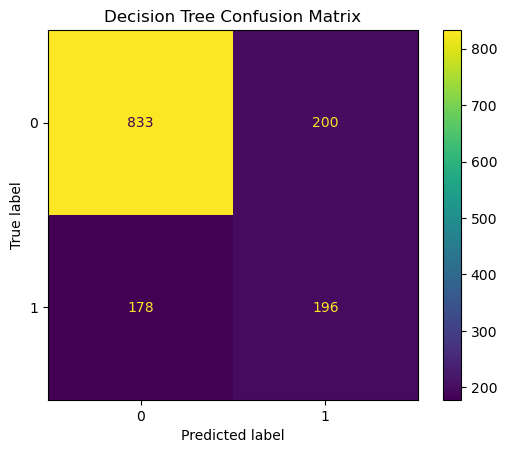

In [54]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Decision Tree Confusion Matrix")

plt.show()

## Decision Tree Results

### Observation

- The Decision Tree model achieved an accuracy of **73.13%**.
- The model correctly predicted **833** non-churn customers and **196** churn customers.
- The recall for churn prediction is **52%**, which is similar to Logistic Regression.
- However, the precision for churn prediction is only **49%**, indicating a higher number of false positive predictions.
- Overall, the Decision Tree model performed worse than Logistic Regression on this dataset.

### Business Interpretation

Although the Decision Tree identifies a similar proportion of churning customers as Logistic Regression, it incorrectly classifies more loyal customers as potential churners.

This could lead to unnecessary retention campaigns, increasing operational costs. Therefore, the Decision Tree is not the preferred model for this dataset.

# Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

It is widely used for classification problems because of its robustness, ability to handle complex relationships, and strong predictive performance.

Accuracy: 0.7945984363894811
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



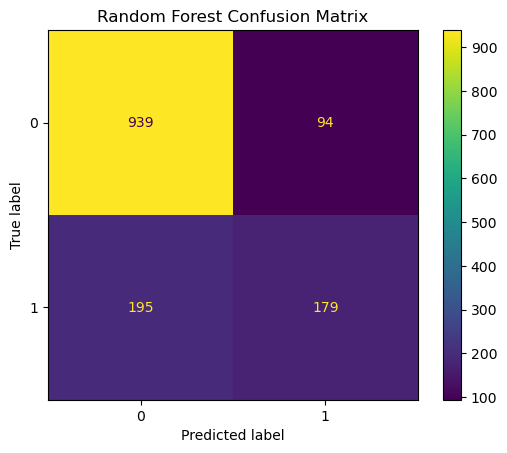

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

## Tuned Random Forest Results

### Observation

- After hyperparameter tuning, the Random Forest model achieved an accuracy of **79.46%**, the highest among all evaluated models.
- The model achieved a precision of **66%** for churn prediction, indicating more reliable positive predictions.
- The recall for churn prediction was **48%**, which is slightly lower than Logistic Regression.
- Overall, hyperparameter tuning improved the model's predictive performance and reduced unnecessary false positive predictions.
- We are saying this model as 'tuned' because we have done some changes in its default parameters.

### Business Interpretation

The tuned Random Forest model provides the best overall prediction accuracy and is effective at identifying customers who are likely to churn.

Although its recall is slightly lower than Logistic Regression, the model produces more reliable churn predictions with fewer false alarms, making it a strong choice for customer retention strategies.

# K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that classifies a data point based on the majority class of its nearest neighbors.

The algorithm predicts customer churn by comparing each customer with similar customers in the training dataset.

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy: 0.749822316986496
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1033
           1       0.53      0.51      0.52       374

    accuracy                           0.75      1407
   macro avg       0.68      0.67      0.67      1407
weighted avg       0.75      0.75      0.75      1407



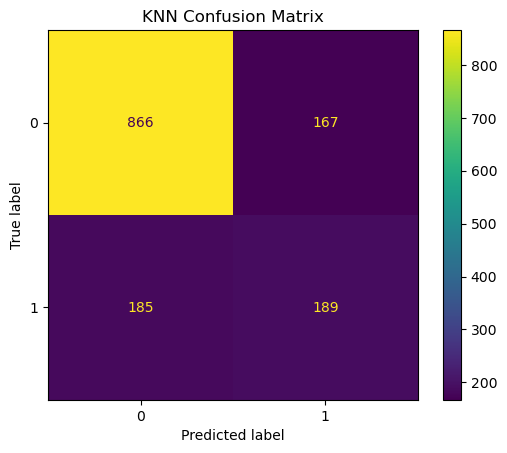

In [58]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("KNN Confusion Matrix")

plt.show()

## K-Nearest Neighbors (KNN) Results

### Observation

- The KNN model achieved an accuracy of **74.98%**.
- The model correctly predicted **866** non-churn customers and **189** churn customers.
- The recall for churn prediction is **51%**, indicating that the model correctly identifies about half of the customers who actually churn.
- Compared to Logistic Regression and the Tuned Random Forest, the KNN model achieved lower overall performance.

### Business Interpretation

Although the KNN model provides reasonable predictions, its lower accuracy and precision make it less suitable for customer churn prediction than the Tuned Random Forest or Logistic Regression.

Therefore, KNN is not selected as the final model for this project.

In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest (Tuned)",
        "KNN"
    ],
    "Accuracy": [
        78.68,
        73.13,
        79.46,
        74.98
    ],
    "Precision": [
        0.62,
        0.49,
        0.66,
        0.53
    ],
    "Recall": [
        0.52,
        0.52,
        0.48,
        0.51
    ],
    "F1 Score": [
        0.56,
        0.51,
        0.55,
        0.52
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,78.68,0.62,0.52,0.56
1,Decision Tree,73.13,0.49,0.52,0.51
2,Random Forest (Tuned),79.46,0.66,0.48,0.55
3,KNN,74.98,0.53,0.51,0.52


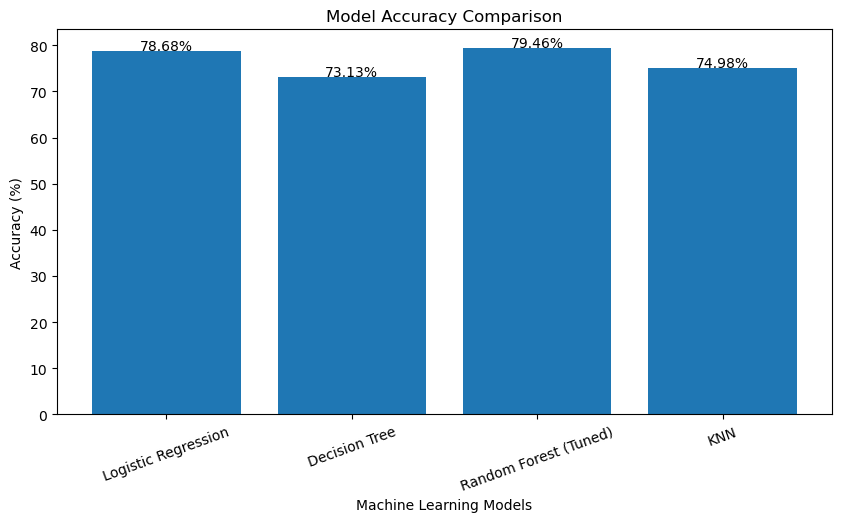

In [62]:
plt.figure(figsize=(10,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=20)

for i, value in enumerate(comparison["Accuracy"]):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha="center")

plt.show()

# Final Model Selection

Four machine learning models were developed and evaluated for customer churn prediction:

- Logistic Regression
- Decision Tree
- K-Nearest Neighbors (KNN)
- Tuned Random Forest

Among all the evaluated models, the **Tuned Random Forest Classifier** achieved the highest overall accuracy (**79.46%**) and the highest precision (**66%**).

Although Logistic Regression achieved a slightly higher recall (**52%**), the Tuned Random Forest provided the best overall balance between prediction accuracy and reliability.

Therefore, the **Tuned Random Forest Classifier** was selected as the final model for customer churn prediction.

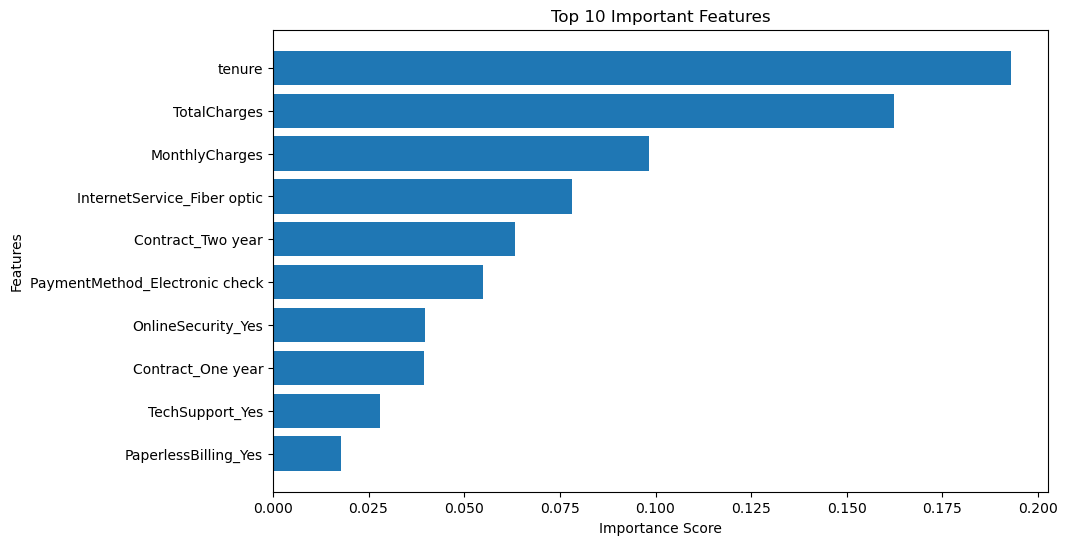

In [64]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.show()

## Feature Importance

The Random Forest model provides feature importance scores that indicate the contribution of each feature to the prediction process.

Understanding feature importance helps identify the most influential factors affecting customer churn and provides valuable business insights.

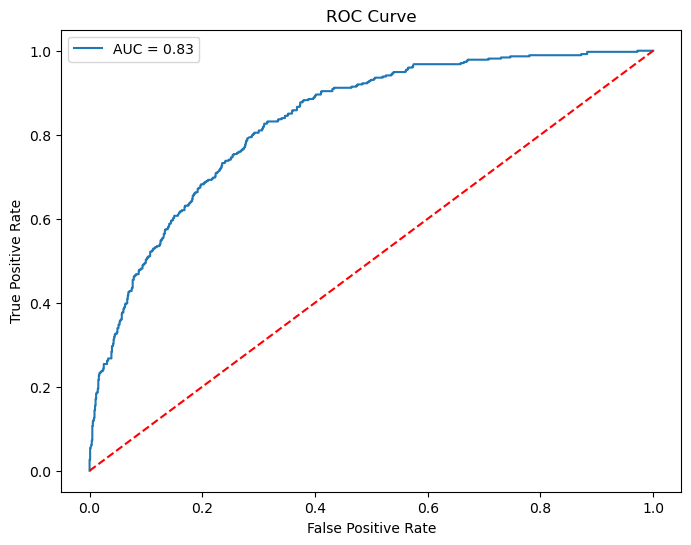

In [65]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## ROC Curve

The Receiver Operating Characteristic (ROC) Curve evaluates the model's ability to distinguish between churned and non-churned customers.

The Area Under the Curve (AUC) summarizes the model's classification performance. A higher AUC value indicates better discrimination between the two classes.

In [66]:
import joblib

joblib.dump(rf,'customer_churn_model.pkl')

['customer_churn_model.pkl']

## Saving the Trained Model

The final machine learning model is saved using the Joblib library.

Saving the trained model enables future predictions without retraining the model.

In [67]:
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [69]:
# import os

# os.makedirs("model", exist_ok=True)
import joblib

joblib.dump(rf, "model/customer_churn_model.pkl")

['model/customer_churn_model.pkl']

In [70]:
joblib.dump(X.columns.tolist(), "model/features.pkl")

['model/features.pkl']

# Project Conclusion

This project successfully developed a machine learning model to predict customer churn using customer demographic information, service details, and billing history.

The project followed a complete data science workflow including:

- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Machine Learning Model Development
- Model Evaluation
- Business Recommendations

Among all the evaluated models, the Tuned Random Forest Classifier achieved the highest overall accuracy of **79.46%** and was selected as the final model.

The analysis revealed that factors such as contract type, tenure, monthly charges, online security, and technical support play significant roles in customer churn.

The developed model can help organizations identify customers who are at high risk of leaving, allowing proactive retention strategies that improve customer satisfaction and reduce revenue loss.

# Future Scope

The current project can be further improved by:

- Collecting additional customer behavioral data.
- Performing advanced hyperparameter optimization.
- Addressing class imbalance using techniques such as SMOTE.
- Deploying the model as a web application using Streamlit.
- Integrating the model with real-time customer databases for live churn prediction.